In [ ]:
import yfinance as yf

df = yf.download('AAPL', start='2008-01-01', end='2024-01-01')

/tmp/ipykernel_2653/1580689108.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2008-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


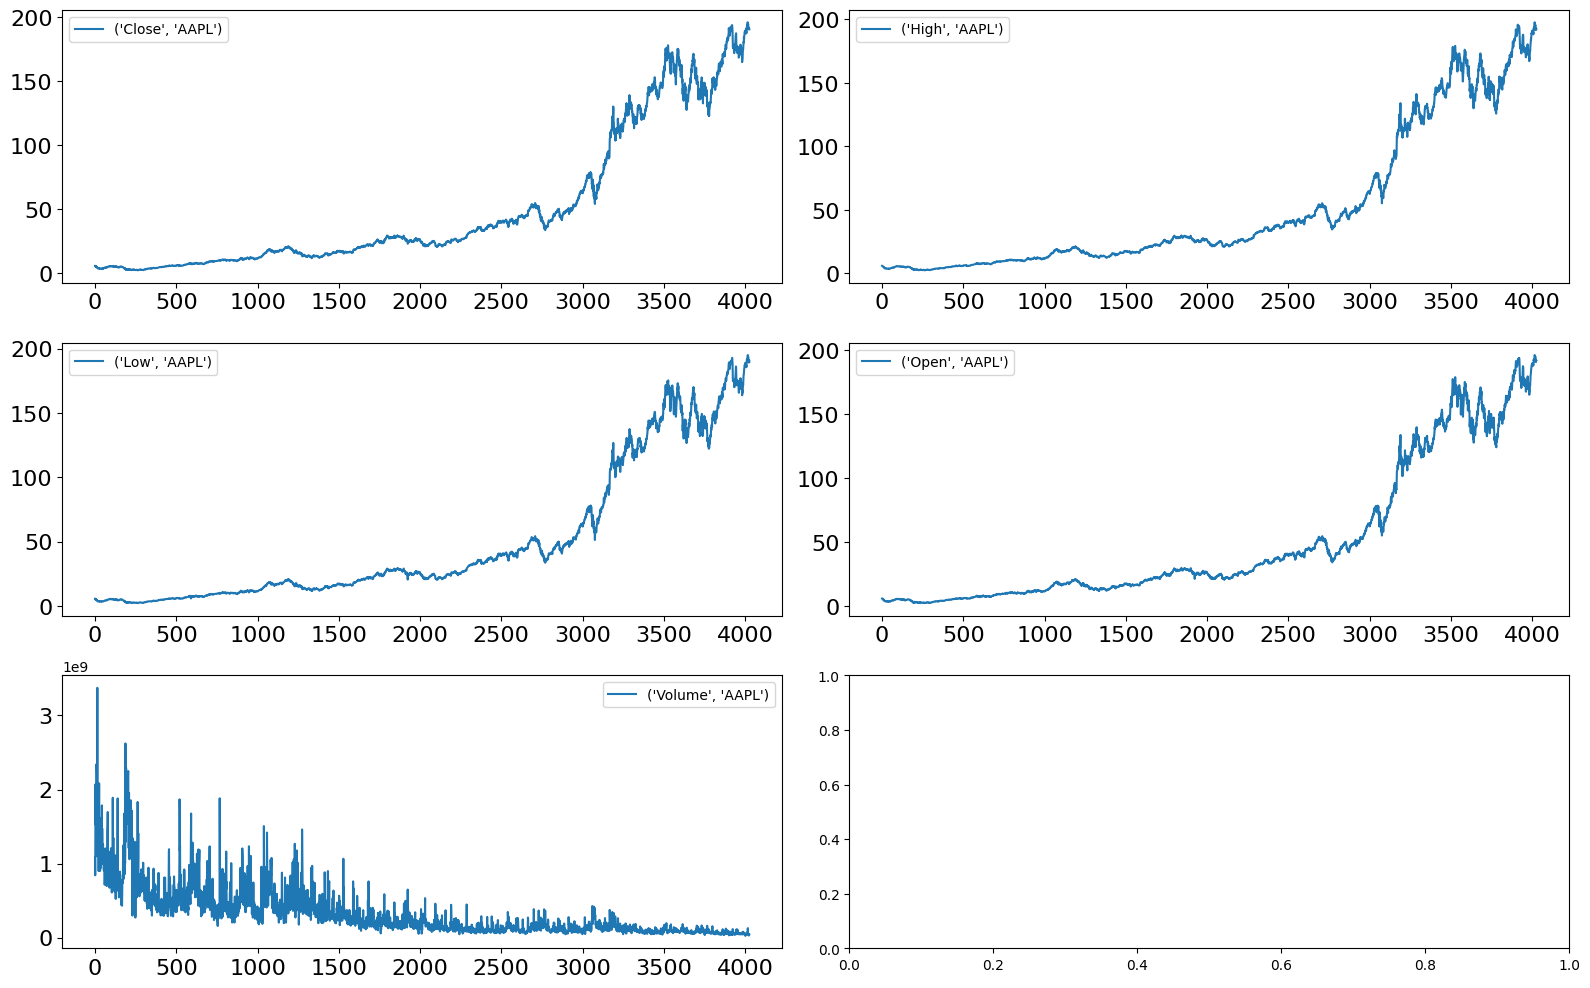

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

df.columns.tolist()
data = df.values
header = df.columns.tolist()
start, days , daily_samples = 0, df.shape[0] , 1
end = start + daily_samples * days

fig, alx = plt.subplots(figsize=(16,10), nrows=3 ,ncols=2)
for i, ax in enumerate(alx.flatten()):
  if i < data.shape[1]:
    ax.plot(np.arange(start,end), data[start:end,i], label = str(header[i]))
    ax.tick_params(axis='both',which='major',labelsize=16)
    ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


In [ ]:
n_samples, n_features = data.shape[0], data.shape[1]
past_seq = 60
lag = 1
target_idx = 4
in_sequences, targets = [], []
for i in range(past_seq, n_samples-lag):
  in_sequences.append(data[i-past_seq:i,:])
  targets.append(data[i:i+lag,target_idx])
in_sequences, targets = np.asarray(in_sequences), np.asarray(targets)

In [ ]:
from torch.mps import is_available
import torch
#Determing device

def get_device():
  if torch.cuda.is_available():
    return torch.device('cuda')
  elif torch.backends.mps.is_available():
    return torch.device('mps')
  else:
    return torch.device('cpu')

In [ ]:
import deeptrack as dt
device = get_device()

/usr/local/lib/python3.12/dist-packages/deeptrack/__init__.py:14: UserWarning: TensorFlow is detected in your environment. DeepTrack2 version 2.0++ no longer supports TensorFlow. If you need TensorFlow support, please install the legacy version 1.7 of DeepTrack2:

    pip install deeptrack==1.7

For more details, refer to the DeepTrack documentation.
  warnings.warn(


In [ ]:
sources = dt.sources.Source(inputs=in_sequences, targets=targets)

train_sources, val_sources = dt.sources.random_split(sources,[0.8,0.2])

In [ ]:
#normalizing the data

train_mean = np.mean([src['inputs'] for src in train_sources],axis=(0,1))
train_std = np.std([src['inputs'] for src in train_sources],axis=(0,1))

inputs_pipeline = (dt.Value(sources.inputs - train_mean)/ train_std
                   >> dt.pytorch.ToTensor(dtype=torch.float))

targets_pipeline = (dt.Value(sources.targets - train_mean[target_idx])
                  /train_std[target_idx]
                   >> dt.pytorch.ToTensor(dtype=torch.float))


In [ ]:
from torch.utils.data import DataLoader

train_dataset = dt.pytorch.Dataset(inputs_pipeline&targets_pipeline,
                                   inputs=train_sources)
val_dataset = dt.pytorch.Dataset(inputs_pipeline&targets_pipeline,
                                 inputs=val_sources)

train_loader = DataLoader(train_dataset, batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
import torch.nn as nn
rnn  = nn.LSTM(
    input_size=in_sequences.shape[2], #no of features
    hidden_size=32,
    batch_first=True
)
fc = nn.Linear(in_features=32, out_features= 1)

rnn.to(device);fc.to(device)

Linear(in_features=32, out_features=1, bias=True)

In [ ]:
criterion = nn.L1Loss()
parameters = list(rnn.parameters()) + list(fc.parameters())
optimizer = torch.optim.Adam(parameters,lr=0.001)

epochs = 100
train_losses, val_losses = [], []
for epoch in range(epochs):
  train_loss = 0.0
  for in_sequences, targets in train_loader:
    optimizer.zero_grad()
    in_sequences, targets = in_sequences.to(device), targets.to(device)
    hidden_sequences,_ = rnn(in_sequences)
    predictions = fc(hidden_sequences[:,-1,:])

    loss = criterion(predictions,targets)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  train_losses.append(train_loss/len(train_loader))
  print(f'Epochs {epoch} train_loss {train_losses[-1]:.4f}')

  val_loss = 0.0
  with torch.no_grad():
    for in_sequences, targets in val_loader:
      in_sequences, targets = in_sequences.to(device), targets.to(device)
      hidden_sequences,_= rnn(in_sequences)
      predictions = fc(hidden_sequences[:,-1,:])

      loss = criterion(predictions, targets)
      val_loss += loss.item()
    val_losses.append(val_loss/len(val_loader))
    print(f'Epochs {epoch} Validation Loss {val_losses[-1]:.4f}')




Epochs 0 train_loss 0.3678
Epochs 0 Validation Loss 0.2733
Epochs 1 train_loss 0.2397
Epochs 1 Validation Loss 0.2611
Epochs 2 train_loss 0.2286
Epochs 2 Validation Loss 0.2498
Epochs 3 train_loss 0.2244
Epochs 3 Validation Loss 0.2428
Epochs 4 train_loss 0.2195
Epochs 4 Validation Loss 0.2396
Epochs 5 train_loss 0.2188
Epochs 5 Validation Loss 0.2358
Epochs 6 train_loss 0.2176
Epochs 6 Validation Loss 0.2326
Epochs 7 train_loss 0.2137
Epochs 7 Validation Loss 0.2310
Epochs 8 train_loss 0.2146
Epochs 8 Validation Loss 0.2285
Epochs 9 train_loss 0.2131
Epochs 9 Validation Loss 0.2238
Epochs 10 train_loss 0.2125
Epochs 10 Validation Loss 0.2233
Epochs 11 train_loss 0.2110
Epochs 11 Validation Loss 0.2263
Epochs 12 train_loss 0.2105
Epochs 12 Validation Loss 0.2242
Epochs 13 train_loss 0.2097
Epochs 13 Validation Loss 0.2234
Epochs 14 train_loss 0.2121
Epochs 14 Validation Loss 0.2205
Epochs 15 train_loss 0.2071
Epochs 15 Validation Loss 0.2207
Epochs 16 train_loss 0.2084
Epochs 16 Valida

In [ ]:
def plot_data(train_losses, val_losses, epochs):
  plt.plot(range(epochs), train_losses,label='Train Loss')
  plt.plot(range(epochs), val_losses,'--', label='Validation Loss')
  plt.legend(fontsize=12)
  plt.show()

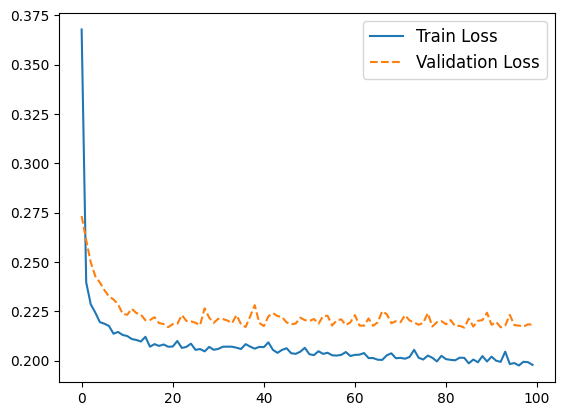

In [ ]:
plot_data(train_losses, val_losses, epochs=100)

In [ ]:
import deeplay as dl

In [ ]:
rnn_dl = dl.RecurrentModel(
    in_features=in_sequences.shape[2],
    hidden_features=[32],
    out_features=1,
    rnn_type='LSTM',
)
rnn_model = dl.Regressor(model=rnn_dl, optimizer=dl.Adam(lr=0.001)).create()

In [ ]:
trainer = dl.Trainer(max_epochs=100, accelerator='auto')
trainer.fit(rnn_model, train_loader, val_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss           │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ RecurrentModel   │  5.0 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 5.0 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.0 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

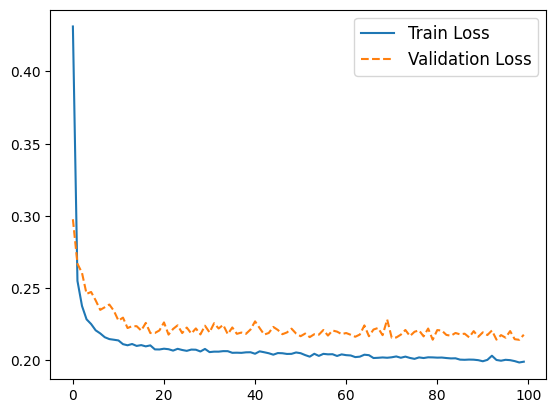

In [ ]:
train_losses_dl= trainer.history.history['train_loss_epoch']['value']
val_losses_dl = trainer.history.history['val_loss_epoch']['value'][1:]

plot_data(train_losses_dl, val_losses_dl, 100)


In [ ]:
import nbformat
nb = nbformat.read("notebook.ipynb", as_version=nbformat.NO_CONVERT)
if "widgets" in nb.metadata and "state" not in nb.metadata.widgets:
  nb.metadata["widgets"] = {"state": {}}
nbformat.write(nb, "notebook_fixed.ipynb")